In [1]:
# Cell 1: Imports & Settings

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="whitegrid")

# Paths (relative to this notebook)
DATA_PATH = Path("../data/processed/inventory_clean.csv")
OUTPUT_DIR = Path("../visuals/charts_from_notebook")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH.resolve()}")
print(f"Charts will be saved to: {OUTPUT_DIR.resolve()}")


Data path: C:\Users\Charan\Music\PERSONAL\Github_Projects\Daxwell-SupplyChain-Analytics\data\processed\inventory_clean.csv
Charts will be saved to: C:\Users\Charan\Music\PERSONAL\Github_Projects\Daxwell-SupplyChain-Analytics\visuals\charts_from_notebook


In [2]:
# Cell 2: Load inventory data

inventory_df = pd.read_csv(DATA_PATH)

# Parse date column
inventory_df["date"] = pd.to_datetime(inventory_df["date"], errors="coerce")

print("Shape:", inventory_df.shape)
inventory_df.head()


Shape: (15000, 11)


,date,sku,supplier_id,inventory_level,reorder_point,reorder_qty,on_order_qty,lead_time_days,reorder_flag,inventory_status,days_of_cover_estimate
0,2024-01-01,SKU-10000,SUP-240,936,306,1595,0,7,False,Healthy,5.9
1,2024-01-01,SKU-10001,SUP-207,1607,666,1738,0,13,False,Healthy,9.2
2,2024-01-01,SKU-10002,SUP-201,1485,572,1623,0,10,False,Healthy,9.1
3,2024-01-01,SKU-10003,SUP-247,168,543,1937,1937,8,True,Critical,0.9
4,2024-01-01,SKU-10004,SUP-217,2503,360,959,0,12,False,Healthy,26.1


In [3]:
# Cell 3: Basic overview

display(inventory_df.describe(include="all").T)
print("\nNull counts:\n")
print(inventory_df.isnull().sum())


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,15000,NaN,NaN,NaN,2024-01-15 12:00:00,2024-01-01 00:00:00,2024-01-08 00:00:00,2024-01-15 12:00:00,2024-01-23 00:00:00,2024-01-30 00:00:00,NaN
sku,15000,500,SKU-10499,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,15000,50,SUP-234,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inventory_level,15000.0,NaN,NaN,NaN,1530.721733,0.0,772.0,1498.0,2234.0,3558.0,897.495513
reorder_point,15000.0,NaN,NaN,NaN,497.982067,200.0,349.0,498.0,646.0,799.0,172.785797
reorder_qty,15000.0,NaN,NaN,NaN,1246.024333,500.0,871.75,1245.0,1615.0,1999.0,431.777797
on_order_qty,15000.0,NaN,NaN,NaN,200.645333,0.0,0.0,0.0,0.0,1999.0,493.059327
lead_time_days,15000.0,NaN,NaN,NaN,8.477533,3.0,6.0,8.0,11.0,14.0,3.439867
reorder_flag,15000,2,False,12614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inventory_status,15000,4,Healthy,12614,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Null counts:

date                      0
sku                       0
supplier_id               0
inventory_level           0
reorder_point             0
reorder_qty               0
on_order_qty              0
lead_time_days            0
reorder_flag              0
inventory_status          0
days_of_cover_estimate    0
dtype: int64


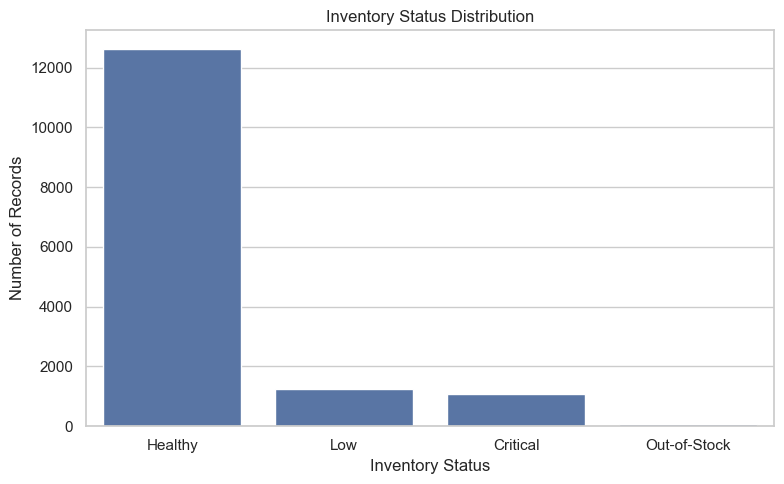

Saved chart to ..\visuals\charts_from_notebook\inventory_status_distribution.png


,inventory_status,count
0,Healthy,12614
1,Low,1239
2,Critical,1091
3,Out-of-Stock,56


In [5]:
# Cell 4 (Fixed Version): Inventory status distribution

# Correctly compute status counts
status_counts = (
    inventory_df["inventory_status"]
    .value_counts()
    .reset_index()
)

# Rename columns explicitly
status_counts.columns = ["inventory_status", "count"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=status_counts,
    x="inventory_status",
    y="count"
)
plt.title("Inventory Status Distribution")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Records")
plt.tight_layout()

output_file = OUTPUT_DIR / "inventory_status_distribution.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved chart to {output_file}")
status_counts


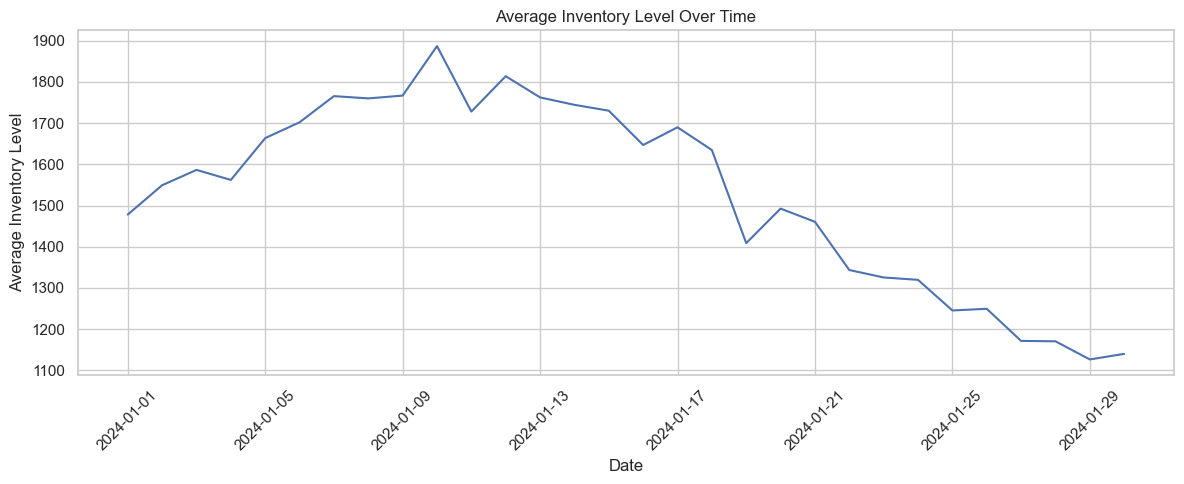

Saved chart to ..\visuals\charts_from_notebook\avg_inventory_level_over_time.png


,date,avg_inventory_level
0,2024-01-01,1478.034
1,2024-01-02,1549.174
2,2024-01-03,1586.298
3,2024-01-04,1561.976
4,2024-01-05,1663.420


In [6]:
# Cell 5: Average inventory level over time

daily_inventory = (
    inventory_df
    .groupby("date", as_index=False)["inventory_level"]
    .mean()
    .rename(columns={"inventory_level": "avg_inventory_level"})
)

plt.figure(figsize=(12, 5))
plt.plot(daily_inventory["date"], daily_inventory["avg_inventory_level"])
plt.title("Average Inventory Level Over Time")
plt.xlabel("Date")
plt.ylabel("Average Inventory Level")
plt.xticks(rotation=45)
plt.tight_layout()

output_file = OUTPUT_DIR / "avg_inventory_level_over_time.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved chart to {output_file}")
daily_inventory.head()


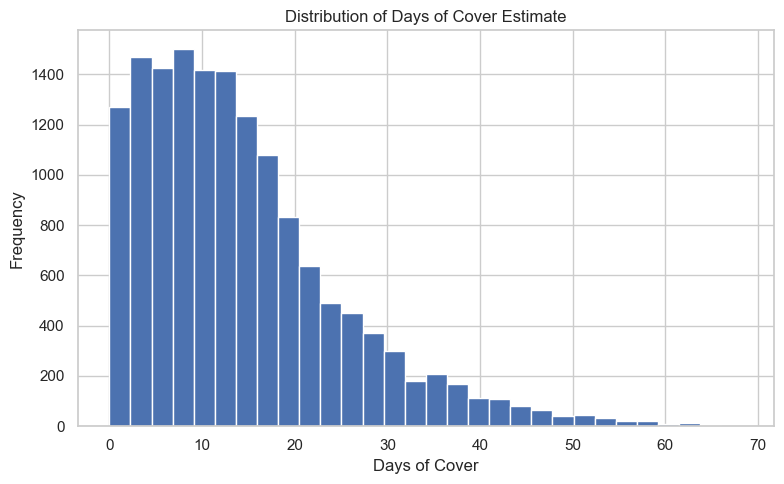

Saved chart to ..\visuals\charts_from_notebook\days_of_cover_distribution.png


In [7]:
# Cell 6: Days of cover distribution

plt.figure(figsize=(8, 5))
valid_doc = inventory_df["days_of_cover_estimate"].replace([np.inf, -np.inf], np.nan).dropna()

plt.hist(valid_doc, bins=30)
plt.title("Distribution of Days of Cover Estimate")
plt.xlabel("Days of Cover")
plt.ylabel("Frequency")
plt.tight_layout()

output_file = OUTPUT_DIR / "days_of_cover_distribution.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved chart to {output_file}")


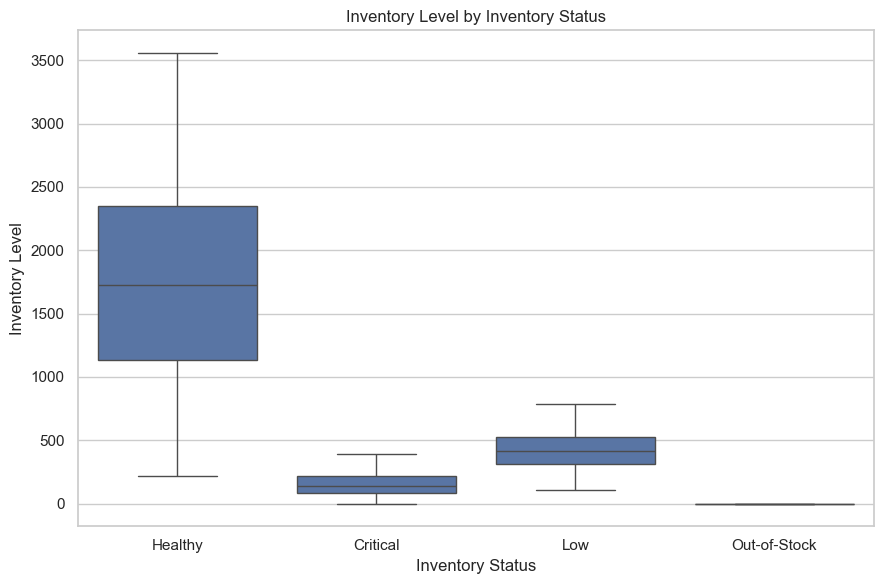

Saved chart to ..\visuals\charts_from_notebook\inventory_level_by_status_boxplot.png


In [8]:
# Cell 7: Inventory level by status (boxplot)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=inventory_df,
    x="inventory_status",
    y="inventory_level"
)
plt.title("Inventory Level by Inventory Status")
plt.xlabel("Inventory Status")
plt.ylabel("Inventory Level")
plt.tight_layout()

output_file = OUTPUT_DIR / "inventory_level_by_status_boxplot.png"
plt.savefig(output_file, dpi=300)
plt.show()

print(f"Saved chart to {output_file}")


In [9]:
# Cell 8: Top 20 high-risk SKUs (Out-of-Stock / Critical, low days of cover)

risk_df = (
    inventory_df[
        inventory_df["inventory_status"].isin(["Out-of-Stock", "Critical", "Low"])
    ]
    .copy()
)

risk_df = risk_df.sort_values(
    by=["inventory_status", "days_of_cover_estimate", "inventory_level"],
    ascending=[True, True, True]
)

top_20_risk_skus = (
    risk_df.groupby(["sku", "supplier_id", "inventory_status"], as_index=False)
    .agg({
        "inventory_level": "mean",
        "reorder_point": "mean",
        "days_of_cover_estimate": "mean"
    })
    .sort_values(
        by=["inventory_status", "days_of_cover_estimate", "inventory_level"],
        ascending=[True, True, True]
    )
    .head(20)
)

top_20_risk_skus.style.background_gradient(cmap="Reds")


,sku,supplier_id,inventory_status,inventory_level,reorder_point,days_of_cover_estimate
564,SKU-10290,SUP-226,Critical,2.000000,710.000000,0.000000
813,SKU-10418,SUP-223,Critical,22.000000,401.000000,0.100000
421,SKU-10217,SUP-231,Critical,22.000000,700.000000,0.150000
393,SKU-10203,SUP-238,Critical,27.000000,749.000000,0.200000
639,SKU-10327,SUP-231,Critical,28.000000,635.000000,0.200000
679,SKU-10347,SUP-212,Critical,28.000000,705.000000,0.200000
328,SKU-10168,SUP-243,Critical,30.000000,271.000000,0.200000
729,SKU-10375,SUP-236,Critical,33.000000,681.000000,0.200000
535,SKU-10277,SUP-236,Critical,39.000000,425.000000,0.200000
494,SKU-10257,SUP-214,Critical,41.000000,324.000000,0.200000


In [10]:
# Cell 9: Quick textual summary (you can rephrase for README/video)

total_records = len(inventory_df)
status_breakdown = inventory_df["inventory_status"].value_counts(normalize=True) * 100

print(f"Total inventory snapshot records: {total_records:,}\n")
print("Inventory status mix (% of records):\n")
print(status_breakdown.round(2))

avg_doc = inventory_df["days_of_cover_estimate"].mean()
print(f"\nAverage days of cover across all SKUs: {avg_doc:.1f} days")


Total inventory snapshot records: 15,000

Inventory status mix (% of records):

inventory_status
Healthy         84.09
Low              8.26
Critical         7.27
Out-of-Stock     0.37
Name: proportion, dtype: float64

Average days of cover across all SKUs: 14.3 days
